<a href="https://colab.research.google.com/github/YafetG3/A03-knn/blob/main/Assignment_3(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

## Assignment 3: $k$ Nearest Neighbor


**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Yafet Getachew

**Date:** 09/30/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


**Q1.**
1. Regression is essentially a prediction of a numeric outcome, while classification is the prediction of a category that the instacne belongs to. Further simplfied, regression is how much of something that instance/subject has, while classifciation is identifying what that something is.  
2. A confusion table is a table consisting of rows which are actual classes and columns which are predictions and they helps us understand how accurate our classification was by counting true negatives and true positives.
3.SSE, or "Sum of Squared Error," measures how far off the model's prediction are from teh actual real-world values, basically, how accurate the regression is.
4. Overfitting could be exemplfified by a jumpy and erratic prediction line that tries to perfectly touch or match every/too many data points including random noise/errors. It can occur when a model memorizes training data rather than learning the pattern. Underfitting happens when the model is too simple and can look like an overly smooth or flat prediction line. It can occur by averaging too many neighbors together, washing out all meaningful patterns.  
5. Because it allows us to check how well the model predicts new observations. It allows us to prevent under/overfitting by comparing training accuracy/SSE to test accuracy/SSE. It simulates on data it hasn't seen yet testing and showing how the model would handle real world scenarios, the idea of generalization.
6. Some strengths of reporting a class label as a prediction could include simplicity, as end users/downstream systems get an immediate, clear answer without actually needing to interpret any numbers, and lower computing overhead, as storing or passing a single categorical label requires fewer bits compared to an entire vector of  floating-point probabilities. Although, some negatives coudl include how lossy it is as it hides how confident or uncratin the model is, and doesn't handle close calls well by treating boarderline cases harshly.  Reporting class labels as a probability distribution has it's own strengths and wekanesses. Some strengths include, it gives you mroe flexibility and quantifies uncertainty which is more info allowing you the option to even flag certain instances for further review. Some negatives include how it requires calibration, as many models output scores that don't reflect actual probabilities and require some sort of translation, there is also an increase in responsibility of and end-user/downstream users as they now have to handle custom operating threshold themselves.

**Q2.**

1. Load the data. Perform some EDA, summarizing the target label and the features.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/YafetG3/A03-knn/main/data/land_mines.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(338, 4)


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [ ]:
df.isna().sum()

,0
voltage,0
height,0
soil,0
mine_type,0


In [ ]:
df["mine_type"].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


In [ ]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [ ]:
df.groupby("mine_type")[["voltage", "height", "soil"]].mean()

,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y, test_size=0.50, random_state=65
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_valid = scaler.transform(X_valid_raw)

print(y_train.value_counts().sort_index())
print(y_valid.value_counts().sort_index())

mine_type
1    37
2    32
3    36
4    28
5    36
Name: count, dtype: int64
mine_type
1    34
2    38
3    30
4    38
5    29
Name: count, dtype: int64


3. Build a $k$-NN classifier. Explain how you select $k$.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

ks = np.arange(1, 51)
train_acc = []
valid_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train, y_train)
    train_acc.append(np.mean(model.predict(X_train) == y_train))
    valid_acc.append(np.mean(model.predict(X_valid) == y_valid))

k_star = int(ks[np.argmax(valid_acc)])
print("best k:", k_star, " validation accuracy:", round(max(valid_acc), 3))

best k: 2  validation accuracy: 0.45


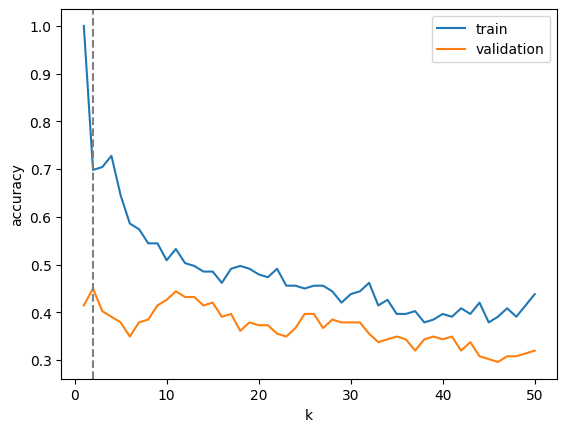

In [ ]:
plt.plot(ks, train_acc, label="train")
plt.plot(ks, valid_acc, label="validation")
plt.axvline(k_star, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.show()

I trained a kNN model for every k from 1 to 50 and compared accuracy on the validation set, since training accuracy always favors k = 1. I chose k = 2 since that's where validation accuracy was highest at ~45%. This makes sense because small k tends to trust one neighbor too much, so one weird reading can "fool" it too much. On the other hand, large k asks too many neighbors, and most of them are different mines tested under the same conditions, so the vote doesn't mean much. k = 2 sits close enough between the two to stay precise with just a bit of backup from neighbors. Something I definitely realize and should mention is that with k = 2, ties between two classes are broken by leaning toward the lower label, so type 1 ('no mine') wins any tie it's part of, meaning any time a real mine's two neighbors are one "no mine" reading and one mine reading, the model says "no mine."

4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?


In [ ]:
model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_valid)

pd.crosstab(y_valid, y_hat, rownames=["actual"], colnames=["predicted"])

predicted,1,2,3,4,5
actual,,,,,
1,21,1,6,4,2
2,0,33,2,3,0
3,5,5,10,6,4
4,13,5,10,9,1
5,10,1,8,7,3


In [ ]:
print("accuracy:", round(np.mean(y_hat == y_valid), 3))

accuracy: 0.45


5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.


As the question has made it clear, a model can have accurate predictions but still make a lot of mistakes which is why I wouldn't use this model to make any decisions on its own, mostly because the mistakes it makes aren't equally dangerous. The biggest problem can be boiled down to how the model predicted "no mine" 49 times, but only 21 of those were actually empty ground. So even though the model gets a fair number of no-mine readings right, when it says "no mine" it's wrong more than half the time. This mistake is fatal as someone would think it's a safe spot if they relied only on this model while in actuality there's a mine there. I'm realizing this could be a direct example of the caveat of choosing k = 2 I made clear earlier, since ties are broken toward type 1. This is exactly why my advice would be to never use a "no mine" prediction to clear ground. Every reading should be treated as a possible mine until someone confirms it with proper equipment. This model should only be used as an indicator and to help in decision making, similar to how I believe AI should be used, not as a repalcement but an aid. I also advise that one shouldn't rely on the specific anti-personnel type since the model had a hard time identifying them because they were similar in voltages. Which is why I'd advise to treat any type 3, 4, or 5 prediction as "anti-personnel, type uncertain," and handle it as if it might be booby-trapped. Another thing I'd tie with the advice I give is to be cognizant of the fact that the data it's built on is small (338 readings) and come from a controlled experiment with 6 soil types and heights up to 20 cm, so real field conditions could make the model perform worse.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]